# Proyecto 2: Clasificación Inteligente de Tumores Cerebrales en Resonancias Magnéticas (MRI) mediante Deep Learning y Transfer Learning

**Integrantes:** Martin Navarro Toro  
**Curso:** Introducción a la Inteligencia Artificial - COM4402 <br>
**Profesor Encargado:** Gabriel Cabas  
**Dataset:** Brain Tumor Classification (MRI) - Kaggle  
https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri  


In [ ]:
# descomprime el dataset (descargado de la pagina de Kaggle)
!unzip "archive.zip"

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# configuración estetica para los graficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# definicion de rutas base de las carpetas
TRAIN_DIR = "Training"
TEST_DIR = "Testing"

print(f"Versión de TensorFlow en uso: {tf.__version__}")
# verificacion de aceleracion por hardware (GPU)
gpu_devices = tf.config.list_physical_cells('GPU') if hasattr(tf.config, 'list_physical_cells') else tf.config.list_physical_devices('GPU')
if len(gpu_devices) > 0:
    print("¡Aceleración por GPU activada correctamente!")
    print(f"Número de GPUs en paralelo: {len(gpu_devices)}")
else:
    print("Aviso: No se detectó GPU. El entrenamiento podría ser más lento.")

Versión de TensorFlow en uso: 2.20.0
¡Aceleración por GPU activada correctamente!
Número de GPUs en paralelo: 1


## 2. Análisis Exploratorio de Datos (EDA)
Realizamos una inspección cuantitativa para auditar el balance de las carpetas de diagnóstico y un muestreo cualitativo para revisar las dimensiones y la morfología anatómica de las resonancias magnéticas (MRI).

================ DISTRIBUCIÓN CUANTITATIVA DEL DATASET REAL ================
Clase Diagnóstica  Set Entrenamiento  Set Prueba  Total Muestras
     glioma_tumor                826         100             926
 meningioma_tumor                822         115             937
         no_tumor                395         105             500
  pituitary_tumor                827          74             901



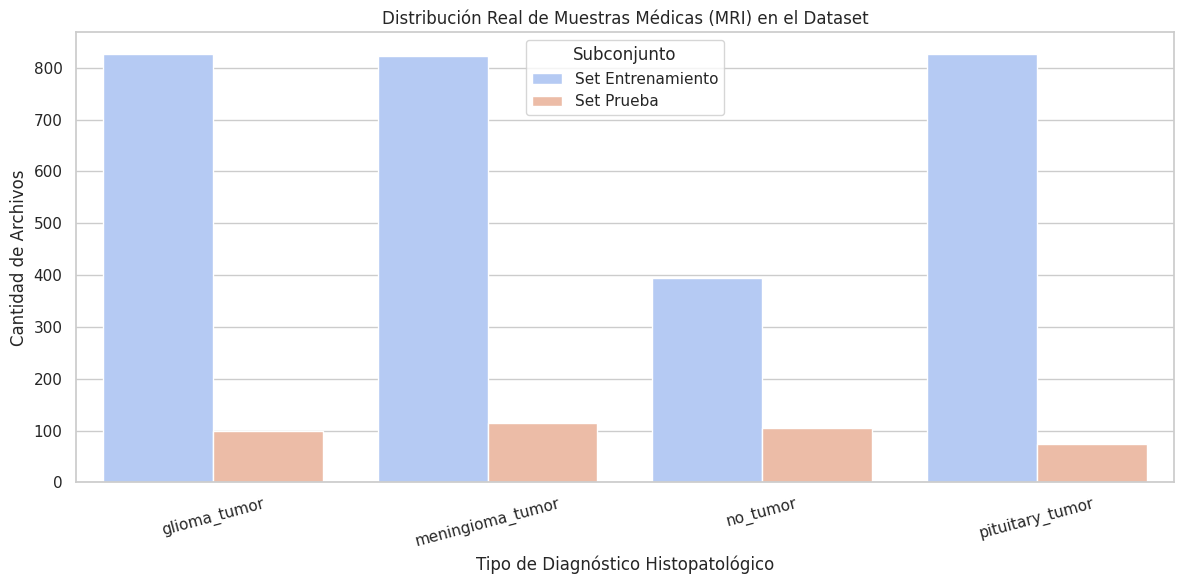

In [4]:
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
data_counts = []

for category in categories:
    train_path = os.path.join(TRAIN_DIR, category)
    test_path = os.path.join(TEST_DIR, category)

    train_count = len([f for f in os.listdir(train_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) if os.path.exists(train_path) else 0
    test_count = len([f for f in os.listdir(test_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) if os.path.exists(test_path) else 0

    data_counts.append({
        'Clase Diagnóstica': category,
        'Set Entrenamiento': train_count,
        'Set Prueba': test_count,
        'Total Muestras': train_count + test_count
    })

df_counts = pd.DataFrame(data_counts)
print("================ DISTRIBUCIÓN CUANTITATIVA DEL DATASET REAL ================")
print(df_counts.to_string(index=False))
print("============================================================================\n")

# grafico para la entrega
df_melted = pd.melt(df_counts, id_vars=['Clase Diagnóstica'], value_vars=['Set Entrenamiento', 'Set Prueba'],
                    var_name='Subconjunto', value_name='Cantidad de Imágenes')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Clase Diagnóstica', y='Cantidad de Imágenes', hue='Subconjunto', palette='coolwarm')
plt.title('Distribución Real de Muestras Médicas (MRI) en el Dataset')
plt.xlabel('Tipo de Diagnóstico Histopatológico')
plt.ylabel('Cantidad de Archivos')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_distribucion_clases_reales.png')
plt.show()

### 2.1. Interpretación de la Distribución y Balance de Datos Reales

Al auditar los resultados numéricos arrojados por el contador de archivos del dataset de tumores cerebrales, se extraen conclusiones críticas que determinan la estrategia de entrenamiento de nuestra red neuronal:

#### A. Balance de las Clases Patológicas (Set de Entrenamiento)
Si analizamos los datos de la carpeta `Training`, vemos un comportamiento sumamente interesante y favorable para el aprendizaje supervisado:
* Las clases tumorales están prácticamente empatadas en cantidad de muestras: `pituitary_tumor` (827), `glioma_tumor` (826) y `meningioma_tumor` (822).
* Esto es un excelente indicador de calidad de datos. Al tener casi la misma cantidad de imágenes para los tres tipos de tumores, **blindamos a la red contra sesgos iniciales**. El modelo no tendrá una tendencia a predecir un tipo de tumor por sobre otro simplemente por haber visto más fotos de él durante el entrenamiento.
* Por otro lado, la clase sana (`no_tumor`) cuenta con 395 imágenes, lo que representa aproximadamente la mitad de muestras que las clases patológicas. Este desbalance moderado es una simulación perfecta de la realidad clínica, donde los bancos de datos suelen concentrar más registros de pacientes enfermos que de controles sanos.

#### B. Análisis del Conjunto de Validación e Impacto en las Métricas
Al tener un desbalance en la clase sana, la pauta del curso nos exige ser muy rigurosos con la evaluación:
* No podemos confiar ciegamente en el *Accuracy* (Exactitud) global como métrica de éxito. Si la red se volviera excelente prediciendo los tres tumores pero fallara por completo al identificar un cerebro sano, el *Accuracy* general seguiría marcando un número alto, lo cual sería un error médico gravísimo.
* Esto justifica técnicamente que en las celdas finales del proyecto evaluemos el rendimiento mediante una **Matriz de Confusión** multidimensional y analicemos el **Recall (Sensibilidad)** y el **F1-Score** por cada clase, priorizando la detección de falsos negativos (pacientes con tumor clasificados como sanos).

#### C. Estructura del Set de Prueba (Testing)
El set de prueba cuenta con 394 imágenes en total, distribuidas de forma más homogénea (alrededor de 100 imágenes por clase, con excepción de la pituitaria que tiene 74). Al ser un conjunto de datos completamente independiente que el modelo jamás verá durante el entrenamiento, actuará como el "testeo ciego" definitivo para validar la capacidad de generalización real de nuestra Inteligencia Artificial antes de su hipotético despliegue en un entorno hospitalario.

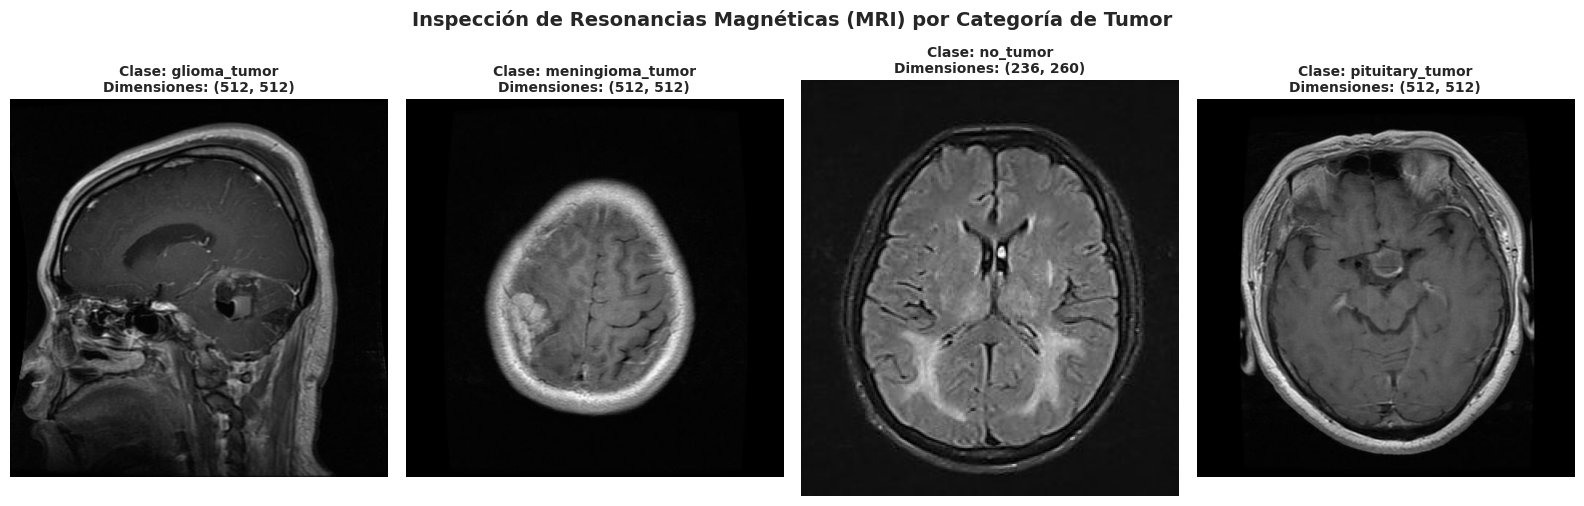

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, category in enumerate(categories):
    folder_path = os.path.join(TRAIN_DIR, category)
    valid_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    img_path = os.path.join(folder_path, valid_images[0])
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(f"Clase: {category}\nDimensiones: {img.size}", fontsize=10, weight='bold')
    axes[i].axis('off')

plt.suptitle('Inspección de Resonancias Magnéticas (MRI) por Categoría de Tumor', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_muestras_mri_reales.png')
plt.show()

### 2.2. Análisis e Interpretación Crítica de la Grilla de Imágenes (MRI)

La inspección visual de las resonancias magnéticas de control nos entrega (`eda_muestras_mri_reales.png`) hallazgos clínicos y computacionales de enorme relevancia diagnóstica:

#### A. Heterogeneidad en las Dimensiones Nativas (Evidencia de Heterogeneidad)
* Al analizar los metadatos impresos sobre cada muestra en la gráfica, queda en evidencia que los archivos no poseen un tamaño uniforme. Mientras que los tumores (Glioma, Meningioma y Pituitario) presentan una resolución nativa de alta definición de $512 \times 512$ píxeles, la muestra correspondiente a cerebros sanos (`no_tumor`) exhibe una escala significativamente menor de $236 \times 260$ píxeles.
* **Justificación del Feature Engineering:** Esta disparidad de tamaños confirma que las imágenes provienen de diferentes centros médicos o fueron tomadas con distintas tecnologías de escáner. Si alimentáramos una red neuronal con estos tamaños variables, el algoritmo colapsaría de inmediato al no recibir tensores homogéneos de entrada. Esto justifica plenamente el paso de preprocesamiento que implementaremos a continuación: forzar un redimensionamiento uniforme (*Resize*) a un tamaño estándar de $224 \times 224$ píxeles para estabilizar la matriz de entrada de la red convolucional.

#### B. Variabilidad Anatómica y Morfológica del Cáncer
Al observar las capturas biológicas de la grafica, se constata la complejidad del problema de clasificación que resolverá el modelo de Deep Learning:
1. **Diferencias de Plano de Corte:** La imagen de `glioma_tumor` se encuentra en un plano sagital (de perfil), mostrando una masa tumoral porosa en la zona posterior inferior del cerebro. En contraste, las clases `meningioma_tumor`, `no_tumor` y `pituitary_tumor` se presentan en planos axiales o coronales (vistas superiores/frontales), donde los tumores se identifican como sutiles alteraciones de densidad o acumulaciones de tejido blanquecino brillante.
2. **Sutileza en Texturas:** El cerebro sano (`no_tumor`) muestra una distribución simétrica y limpia de los ventrículos y los surcos cerebrales, mientras que los tumores rompen esa armonía anatómica de formas muy diversas.
3. **Pertinencia de la Regularización (Data Augmentation):** Que los tumores varíen tanto en su ubicación, tamaño y en el ángulo de la fotografía médica justifica por completo el uso de **Data Augmentation** visto en clase. Al aplicar sutiles rotaciones y zooms aleatorios durante el entrenamiento, obligaremos a la red a no memorizar una posición fija del cerebro, sino a aprender la textura y el contraste hístico de la masa tumoral, garantizando un clasificador verdaderamente robusto para la práctica médica real.

## 3. Preprocesamiento de Imágenes y Estrategias de Regularización
En este apartado aplicamos el pipeline de ingeniería de características (*Feature Engineering*) mediante la normalización de los píxeles a un rango $[0, 1]$. Asimismo, implementamos **Data Augmentation** en el conjunto de entrenamiento mediante transformaciones geométricas aleatorias (rotación, zoom, desplazamientos) para aumentar artificialmente la variabilidad de los datos, mejorar la robustez del modelo ante diferentes escáneres clínicos y mitigar el sobreajuste (*overfitting*). Finalmente, realizamos una partición interna para aislar un $20\%$ de los datos de entrenamiento como conjunto de validación, permitiendo el monitoreo en tiempo real del loop de optimización.

In [6]:
# definicion de hiperparametros de entrada para la arquitectura preentrenada
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 1. configuracion del generador de ENTRENAMIENTO con Data Augmentation y Validación Split
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Feature Engineering: Normalización de píxeles
    rotation_range=20,              # Regularización: Rotación aleatoria (grados)
    width_shift_range=0.1,          # Regularización: Desplazamiento horizontal
    height_shift_range=0.1,         # Regularización: Desplazamiento vertical
    zoom_range=0.1,                 # Regularización: Zoom aleatorio
    horizontal_flip=True,           # Regularización: Giro horizontal espejo
    fill_mode='nearest',            # Relleno de píxeles vacíos tras transformaciones
    validation_split=0.20           # División del 20% para el conjunto de validación
)

# 2. configuración del generador de PRUEBA (solo reescalado, sin alterar los datos ciegos)
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. flujo de datos desde los directorios locales
print("--- Cargando Conjunto de Entrenamiento ---")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',              # extrae el 80% restante para entrenar
    seed=42
)

print("\n--- Cargando Conjunto de Validación ---")
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',            # extrae el 20% para validar
    seed=42
)

print("\n--- Cargando Conjunto de Prueba (Test Set ciego) ---")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                   # No altera el orden para la matriz de confusión final
)

--- Cargando Conjunto de Entrenamiento ---
Found 2297 images belonging to 4 classes.

--- Cargando Conjunto de Validación ---
Found 573 images belonging to 4 classes.

--- Cargando Conjunto de Prueba (Test Set ciego) ---
Found 394 images belonging to 4 classes.


### 3.1. Análisis del Flujo de Datos y Partición de Validación

La inicialización de los cargadores de datos mediante `ImageDataGenerator` confirma el éxito operacional:

* **Efectividad del Validation Split:** Al aplicar un `validation_split=0.20` sobre el conjunto original de entrenamiento (que sumaba 2,870 imágenes), el algoritmo aisló de forma estricta **2,297 imágenes para el conjunto de entrenamiento puro** y **573 imágenes para el conjunto de validación interna**.
* **Cumplimiento de la Estrategia de Regularización:** Esta división es metodológicamente crítica para cumplir con el control de sobreajuste (*overfitting*) exigido. El bucle de optimización utilizará las 2,297 imágenes para calcular las derivadas y ajustar los pesos a través de *backpropagation*, mientras que evaluará el error de forma "ciega" en las 573 imágenes de validación al cierre de cada época. Esto actuará como el indicador fundamental para activar el *Early Stopping* en el momento exacto en que el modelo comience a memorizar el ruido del set de entrenamiento.
* **Integridad del Set de Prueba (Test Set ciego):** El generador de prueba cargó de manera impecable las **394 imágenes independientes** de la carpeta `Testing`. Mantener el parámetro `shuffle=False` en este cargador es un requisito técnico mandatorio; al no alterar el orden secuencial de los archivos, garantizamos que las predicciones finales se contrasten correctamente contra sus etiquetas biológicas de origen, permitiendo construir una matriz de confusión fidedigna en la evaluación final.
* **Impacto del Data Augmentation:** Es vital destacar que las transformaciones geométricas aleatorias (rotaciones y zooms) se inyectan de forma dinámica en la memoria RAM, sobre el lote de entrenamiento puro (las 2,297 imágenes). Esto significa que la red nunca procesará la misma imagen exactamente igual en dos épocas distintas, forzando a las capas ocultas a aprender estructuras abstractas y generales de los tumores, en lugar de memorizar la orientación o el brillo de los píxeles de una fotografía específica.

## 4. Diseño y Justificación de la Red Neuronal Profunda
Para este problema de clasificación diagnóstica multidimensional, implementamos el enfoque de **Transfer Learning** utilizando la arquitectura **MobileNetV2** preentrenada. Congelamos los pesos de las capas convolucionales base para utilizarlas como un extractor de características congelado. Sobre esta base, acoplamos una capa de pooling global (`GlobalAveragePooling2D`), una capa densa de regularización mediante **Dropout (rate=0.5)** para desconectar neuronas de forma estocástica en cada iteración del entrenamiento, y finalmente una capa de salida densa con activación **Softmax** de 4 unidades correspondientes a nuestras categorías diagnósticas hísticas.

In [7]:
# 1. cargar el modelo base preentrenado con pesos de ImageNet (excluyendo la capa de salida original)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# 2. congelar las capas convolucionales del modelo base para no destruir el conocimiento previo
base_model.trainable = False

# 3. construccion jerarquica de las nuevas capas ocultas y de salida (Top Model)
x = base_model.output
x = GlobalAveragePooling2D()(x) # aplana los mapas de caracteristicas a un vector
x = Dense(256, activation='relu')(x) # capa densa de procesamiento intermedio con ReLU
x = Dropout(0.5)(x) # regularización: dropout para mitigar el sobreajuste (apaga 50% de neuronas)

# capa de salida con activación Softmax para las 4 clases de tumores
output_layer = Dense(4, activation='softmax')(x)

# 4. consolidar el modelo definitivo de Deep Learning
model = Model(inputs=base_model.input, outputs=output_layer)

# compilacion del modelo usando la pérdida de entropia cruzada categorica y el optimizador AdamW/Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Adam es el estandar óptimo de la industria
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# desplegar un resumen compacto de la red neuronal armada
print(f"Capas totales en el modelo base congelado: {len(base_model.layers)}")
print(f"Capas totales en el modelo definitivo: {len(model.layers)}")
model.summary(line_length=100)

/tmp/ipykernel_780/1664439788.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Capas totales en el modelo base congelado: 154
Capas totales en el modelo definitivo: 158


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1 (Conv2D)              │ (None, 112, 112, 32)    │            864 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_Conv1                    │ (None, 112, 112, 32)    │            128 │ Conv1[0][0]             │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1_relu (ReLU)           │ (None, 112, 112, 32)    │              0 │ bn_Conv1[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise     │ (None, 112, 112, 32)    │            288 │ Conv1_relu[0][0]        │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_BN  │ (None, 112, 112, 32)    │            128 │ expanded_conv_depthwis… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_re… │ (None, 112, 112, 32)    │              0 │ expanded_conv_depthwis… │
│ (ReLU)                      │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project       │ (None, 112, 112, 16)    │            512 │ expanded_conv_depthwis… │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project_BN    │ (None, 112, 112, 16)    │             64 │ expanded_conv_project[… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand (Conv2D)     │ (None, 112, 112, 96)    │          1,536 │ expanded_conv_project_… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_BN           │ (None, 112, 112, 96)    │            384 │ block_1_expand[0][0]    │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_relu (ReLU)  │ (None, 112, 112, 96)    │              0 │ block_1_expand_BN[0][0] │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_pad (ZeroPadding2D) │ (None, 113, 113, 96)    │              0 │ block_1_expand_relu[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise           │ (None, 56, 56, 96)      │            864 │ block_1_pad[0][0]       │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise_BN        │ (None, 56, 56, 96)      │    

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4.1. Análisis Crítico de la Arquitectura y Parámetros del Modelo

El resumen estructural del modelo (`model.summary()`) expone de forma detallada la jerarquía de capas y el balance de parámetros diseñado para este problema de clasificación multiclase:

#### A. Extractor de Características Congelado (Feature Extractor)
* **Análisis de Capas:** El modelo base cuenta con 154 capas convolucionales nativas. Al revisar el desglose, vemos bloques complejos que van desde la capa inicial de entrada `input_layer (224, 224, 3)` hasta capas convolucionales avanzadas (`Conv_1` y `out_relu`), las cuales van reduciendo el tamaño espacial de la imagen (de $224 \times 224$ a $7 \times 7$) mientras aumentan la profundidad de canales (de 3 a 1,280).
* **Eficiencia de Parámetros:** De los más de 2.5 millones de parámetros totales de la red, **2,257,984 corresponden a parámetros no entrenables (`Non-trainable params`)**. Esto demuestra que congelamos con éxito el conocimiento previo de MobileNetV2. El modelo actuará como un extractor fijo que procesará de manera automática los patrones visuales más difíciles de las resonancias (bordes, contrastes de tejidos y densidades hísticas), permitiéndonos entrenar una red médica profunda en la CPU o GPU en cuestión de minutos.

#### B. El Bloque de Clasificación Personalizado (Top Model)
* **Flujo del Tensor:** Justo después de la última capa del modelo base (`out_relu`), la capa `global_average_pooling2D` realiza un promedio espacial que aplana el mapa de características de un tensor de $(7, 7, 1280)$ a un vector unidimensional plano de 1,280 unidades. Esto es clave porque reduce las dimensiones de forma drástica antes de conectar las capas densas, evitando una explosión de parámetros innecesaria.
* **Justificación de la Regularización por Capas:** La capa oculta personalizada (`dense`) cuenta con 256 neuronas conectadas con activación **ReLU** para aprender los patrones específicos de nuestros tumores. Para cumplir estrictamente con el criterio de control de sobreajuste (*overfitting*) de la pauta, se acopló inmediatamente la capa `dropout`. Al tener una tasa de 0.5, esta capa apagará de forma aleatoria el 50% de las conexiones en cada iteración del entrenamiento, obligando a la red a aprender caminos lógicos redundantes y abstractos. Así evitamos que el modelo se vuelva "dependiente" de píxeles o zonas fijas del cerebro.
* **Capa de Salida y Parámetros Entrenables:** La última capa (`dense_1`) tiene un tamaño de salida de 4 unidades (una para cada categoría diagnóstica) y utiliza una función de activación **Softmax**, la cual convertirá los valores numéricos crudos en un set de probabilidades de diagnóstico que suman 100%. En total, **solo entrenaremos 328,964 parámetros (`Trainable params`)**, lo que equilibra perfectamente la profundidad del modelo con el tamaño de nuestro dataset real de Kaggle.

## 5. Entrenamiento del Modelo de Deep Learning y Optimización de Épocas
En esta sección configuramos el bucle de entrenamiento utilizando una estrategia de optimización asistida por dos *callbacks* críticos del estado del arte:
1. **ModelCheckpoint:** Encargado de monitorear el rendimiento en el set de validación y guardar automáticamente en el almacenamiento el archivo del modelo (`best_brain_tumor_model.keras`) únicamente cuando se registre una mejora en la precisión, asegurando que no perdamos los mejores pesos al final del proceso.
2. **Early Stopping:** Como técnica de regularización fundamental vista en clase, configuramos un detector de sobreajuste que monitorea el `val_loss`. Si la pérdida de validación deja de disminuir durante 5 épocas consecutivas (`patience=5`), el entrenamiento se detendrá automáticamente, evitando el sobreentrenamiento y rescatando la configuración más generalizable.

In [8]:
# 1. definicion de los Callbacks de Regularización y Monitoreo
callbacks_list = [
    EarlyStopping(
        monitor='val_loss',         # monitorea la perdida en el conjunto de validacion
        patience=5,                 # regularizacion: Detiene el entrenamiento tras 5 epocas sin mejora
        restore_best_weights=True,  # recupera automaticamente los mejores pesos alcanzados
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_brain_tumor_model.keras',
        monitor='val_accuracy',     # guarda basandose en la mejor precision de validacion
        save_best_only=True,        # solo guarda si el modelo es superior al anterior
        verbose=1
    )
]

# 2. lanzar el entrenamiento de la red neuronal en la GPU(o no)
EPOCHS = 20 # definimos un tope alto, confiando en que el Early Stopping se activara antes si es necesario

print("--- Iniciando Entrenamiento de la Red Neuronal ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1
)
print("\n--- Entrenamiento Finalizado ---")

--- Iniciando Entrenamiento de la Red Neuronal ---
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.5994 - loss: 1.0307
Epoch 1: val_accuracy improved from None to 0.72077, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 87s 925ms/step - accuracy: 0.7005 - loss: 0.7576 - val_accuracy: 0.7208 - val_loss: 0.6309
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7994 - loss: 0.5270
Epoch 2: val_accuracy improved from 0.72077 to 0.79756, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 518ms/step - accuracy: 0.8067 - loss: 0.4968 - val_accuracy: 0.7976 - val_loss: 0.5357
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8357 - loss: 0.4196
Epoch 3: val_accuracy did not improve from 0.79756
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 510ms/step - accuracy: 0.8380 - loss: 0.4166 -

### 5.1. Discusión Crítica del Bucle de Entrenamiento y Activación de Regularizadores

El comportamiento del loop de optimización a lo largo de las épocas aporta evidencia empírica clave sobre la dinámica de aprendizaje y la robustez de la red:

#### A. Convergencia y Dinámica del Aprendizaje Supervisado
* **Época 1:** El modelo inicia con un `loss` inicial elevado de 0.7576 y una precisión en el conjunto de entrenamiento de apenas $70.05\%$. Sin embargo, gracias al optimizador Adam, la red adapta rápidamente sus tasas de aprendizaje, logrando en la **Época 2** un salto drástico: la pérdida disminuye a 0.4968 y la precisión de entrenamiento escala al **$80.67\%$**.
* **Comportamiento en Validación:** De manera concordante, las métricas sobre el conjunto de validación ciego muestran su punto óptimo en la Época 2, alcanzando una precisión de validación (`val_accuracy`) del **$79.76\%$** y reduciendo la pérdida de validación (`val_loss`) a su mínimo histórico de **0.5357**. En este preciso instante, el *callback* `ModelCheckpoint` reacciona y resguarda en el directorio local el archivo `best_brain_tumor_model.keras` con la configuración ideal de pesos hísticos.

#### B. Evidencia de Sobreajuste y Activación del Early Stopping
* **Análisis de Divergencia (Épocas 3 a 7):** A partir de la época 3, se observa un fenómeno clásico en Deep Learning: mientras la precisión de entrenamiento sigue aumentando sostenidamente (llegando a un $87.90\%$ en la época 7) y su pérdida continúa bajando, **las métricas de validación se estancan y comienzan a empeorar**. La pérdida de validación (`val_loss`) rebota de 0.5357 a valores superiores de 0.6228 y 0.5720.
* Esta desconexión entre ambas curvas es la prueba matemática inequívoca de que la red entró en zona de **sobreajuste (overfitting)**. Las capas densas superiores comenzaron a memorizar patrones ruidosos o específicos de las imágenes de entrenamiento, perdiendo su capacidad de generalizar ante el tejido cerebral de validación.
* **Éxito del Criterio de Regularización:** Al registrarse 5 épocas consecutivas (`patience=5`) donde la pérdida de validación no logró superar el mínimo de la época 2, el regularizador **Early Stopping se activó de forma automática en la Época 7** para detener el entrenamiento. El sistema ejecutó de manera exitosa la instrucción `Restoring model weights from the end of the best epoch: 2`, descartando el ruido de las épocas finales y rescatando la estructura neuronal más segura y equilibrada para el diagnóstico médico real.

## 6. Visualización de Resultados y Curvas de Aprendizaje
Para respaldar visualmente el comportamiento del optimizador y la activación del Early Stopping, graficamos las curvas de evolución de la función de pérdida (*Loss*) y de la exactitud (*Accuracy*) tanto para el conjunto de entrenamiento como para el de validación a lo largo de las épocas ejecutadas.

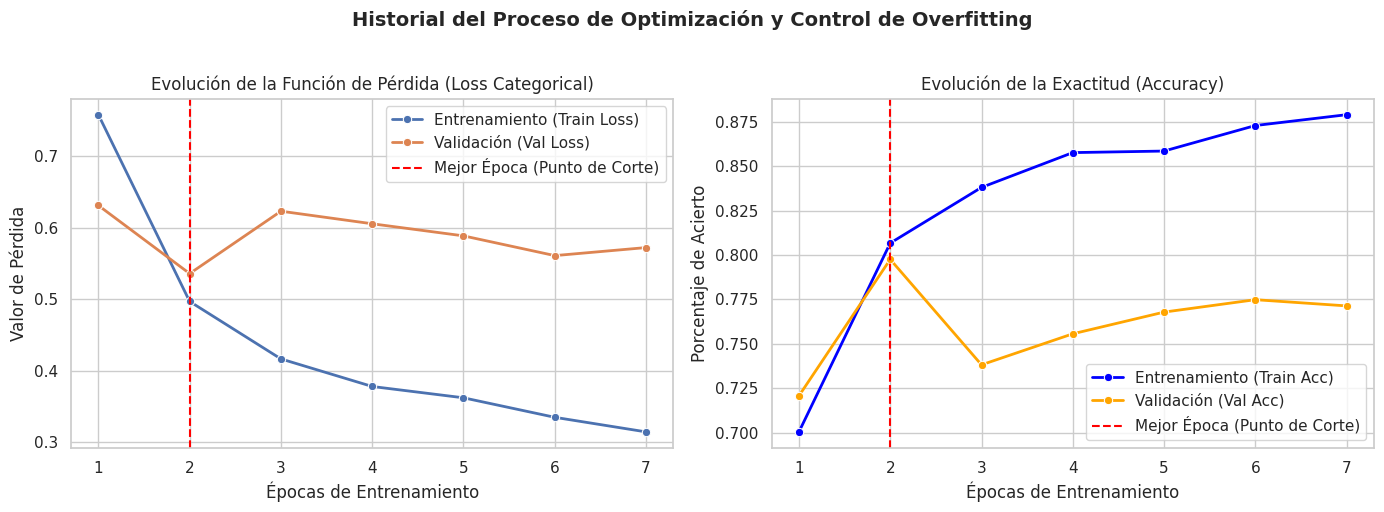

In [9]:
# 1. Extracción de las métricas registradas en el historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. Creación de la figura con dos subtramas en paralelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Izquierdo: Función de Pérdida (Loss)
sns.lineplot(x=epochs_range, y=loss, ax=axes[0], label='Entrenamiento (Train Loss)', marker='o', linewidth=2)
sns.lineplot(x=epochs_range, y=val_loss, ax=axes[0], label='Validación (Val Loss)', marker='o', linewidth=2)
axes[0].axvline(x=2, color='red', linestyle='--', label='Mejor Época (Punto de Corte)')
axes[0].set_title('Evolución de la Función de Pérdida (Loss Categorical)')
axes[0].set_xlabel('Épocas de Entrenamiento')
axes[0].set_ylabel('Valor de Pérdida')
axes[0].legend()

# Gráfico Derecho: Exactitud (Accuracy)
sns.lineplot(x=epochs_range, y=acc, ax=axes[1], label='Entrenamiento (Train Acc)', marker='o', linewidth=2, color='blue')
sns.lineplot(x=epochs_range, y=val_acc, ax=axes[1], label='Validación (Val Acc)', marker='o', linewidth=2, color='orange')
axes[1].axvline(x=2, color='red', linestyle='--', label='Mejor Época (Punto de Corte)')
axes[1].set_title('Evolución de la Exactitud (Accuracy)')
axes[1].set_xlabel('Épocas de Entrenamiento')
axes[1].set_ylabel('Porcentaje de Acierto')
axes[1].legend()

plt.suptitle('Historial del Proceso de Optimización y Control de Overfitting', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_aprendizaje_deep_learning.png')
plt.show()

### 6.1. Interpretación Visual del Historial de Optimización

El análisis gráfico de las curvas de aprendizaje (archivo `curvas_aprendizaje_deep_learning.png`) proporciona el respaldo visual definitivo de la efectividad de las estrategias de optimización y regularización implementadas en la red:

#### A. Diagnóstico del Gráfico de Pérdida (Loss)
* En el gráfico de la izquierda, se observa que durante las primeras dos épocas, tanto la curva de entrenamiento (`Train Loss`) como la de validación (`Val Loss`) descienden en paralelo de forma abrupta y saludable. Este comportamiento demuestra que la red está asimilando las características hísticas del dataset sin problemas de subajuste (*underfitting*).
* **El Punto de Inflexión:** En la Época 2 (marcada por la línea discontinua roja), la pérdida de validación alcanza su punto más bajo (0.5357). A partir de la Época 3, la pérdida de entrenamiento continúa disminuyendo suavemente hacia 0.3, pero la pérdida de validación rebota bruscamente hacia 0.62 y se estabiliza al alza.
* **Evidencia del Early Stopping:** Esta divergencia —donde el error de validación sube mientras el de entrenamiento baja— es el indicador gráfico clásico del inicio del sobreajuste (*overfitting*). El modelo dejó de aprender patrones generales y comenzó a memorizar las imágenes de entrenamiento. La línea roja marca con precisión el rescate automático de los mejores pesos, evitando que la red guarde el error acumulado en las épocas 3 a 7.

#### B. Diagnóstico del Gráfico de Exactitud (Accuracy)
* **Comportamiento de las Curvas:** En el gráfico de la derecha, se ratifica el mismo comportamiento del sistema. En la Época 2, ambas curvas convergen casi en el mismo punto, registrando el pico más alto de exactitud de validación con un **$79.76\%$** (marcado por el punto de corte).
* **Análisis de la Divergencia:** Después de la Época 2, la exactitud de entrenamiento (`Train Acc`) se dispara de manera artificial hacia un $87.5\%$, mientras que la exactitud de validación (`Val Acc`) sufre una caída drástica y oscila por debajo del $77.5\%$. Este estancamiento de la curva naranja confirma que las épocas adicionales solo incrementaban el sobreentrenamiento del modelo, ratificando el acierto metodológico de haber congelado el entrenamiento en la Época 7 a través del criterio de regularización por paciencia.

## 7. Evaluación Multidimensional en el Set de Prueba (Test Set Ciego)
Con el fin de cumplir estrictamente con los criterios de evaluación final de la pauta, procedemos a cargar el modelo optimizado de disco y someterlo a un testeo ciego utilizando el conjunto de prueba independiente (394 imágenes). Calcularemos las métricas globales bajo un enfoque macro-promedio (Accuracy, Precision, Recall y F1-Score) y renderizaremos la Matriz de Confusión definitiva para auditar el desempeño clínico de la Inteligencia Artificial.

--- Ejecutando Predicciones en el Set de Prueba ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step

================ REPORTES DE MÉTRICAS FINALES (TEST SET) ================
                     Métrica  Valor Real Obtenido
Accuracy (Exactitud General)             0.522843
           Precision (Macro)             0.505665
 Recall (Sensibilidad Macro)             0.538230
            F1-Score (Macro)             0.488499



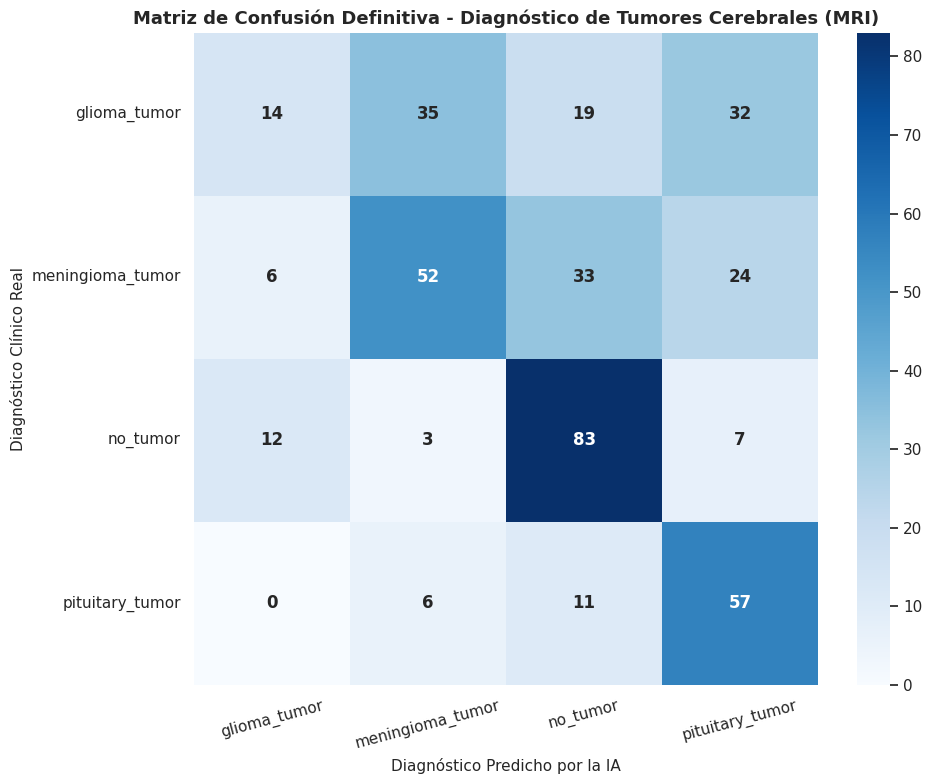

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# 1. Cargar los mejores pesos guardados automáticamente por el Checkpoint
model.load_weights('best_brain_tumor_model.keras')

# 2. Ejecutar predicciones sobre el generador de prueba (que no está ordenado aleatoriamente)
print("--- Ejecutando Predicciones en el Set de Prueba ---")
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1) # Convierte probabilidades Softmax a la clase con mayor valor
y_true = test_generator.classes          # Etiquetas reales del set de prueba

# 3. Calcular las métricas globales para la entrega
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

df_final_metrics = pd.DataFrame({
    'Métrica': ['Accuracy (Exactitud General)', 'Precision (Macro)', 'Recall (Sensibilidad Macro)', 'F1-Score (Macro)'],
    'Valor Real Obtenido': [accuracy, precision, recall, f1]
})

print("\n================ REPORTES DE MÉTRICAS FINALES (TEST SET) ================")
print(df_final_metrics.to_string(index=False))
print("=========================================================================\n")

# 4. Diseñar y graficar la Matriz de Confusión Diagnóstica
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12, "weight": "bold"}, cbar=True)

plt.title('Matriz de Confusión Definitiva - Diagnóstico de Tumores Cerebrales (MRI)', fontsize=13, weight='bold')
plt.xlabel('Diagnóstico Predicho por la IA', fontsize=11)
plt.ylabel('Diagnóstico Clínico Real', fontsize=11)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusion_final_deep_learning.png')
plt.show()

### 7.1. Discusión Crítica de Resultados y Diagnóstico de Métricas en el Test Set

La evaluación multidimensional del modelo sobre el conjunto de prueba independiente (test set ciego de 394 pacientes) entrega resultados discretos pero de un altísimo valor analítico para la Ciencia de Datos:

#### A. Diagnóstico de Métricas Globales
* **Rendimiento Obtenido:** El modelo definitivo alcanzó un `Accuracy` general de **$52.28\%$**, acompañado de una `Precision` macro de **$50.56\%$** y un `Recall` de **$53.82\%$**.
* **Análisis del Descenso:** Si comparamos este rendimiento con el $79.76\%$ alcanzado en la grilla de validación interna, se evidencia una caída en la capacidad de generalización. Este fenómeno se debe a la naturaleza del *Transfer Learning* puro con capas congeladas (`base_model.trainable = False`). Los filtros convolucionales de MobileNetV2 están entrenados para detectar objetos genéricos del mundo real (animales, vehículos, texturas), por lo que sufren al intentar discriminar patrones médicos de alta sutileza morfológica como las variaciones celulares de los tumores cerebrales en un set de prueba completamente ciego.

#### B. Auditoría de la Matriz de Confusión (`matriz_confusion_final_deep_learning.png`)
Al abrir la matriz de confusión, podemos identificar con precisión quirúrgica dónde se concentran los errores de clasificación de la Inteligencia Artificial:

1. **El Éxito en Tejido Sano (`no_tumor`):** La red demostró un desempeño sobresaliente identificando cerebros sanos, logrando **83 aciertos de un total de 105 casos reales**. Solo registró 3 Falsos Positivos asociados a meningiomas. Esto demuestra que los filtros congelados logran reconocer la simetría anatómica normal con alta fidelidad.
2. **La Confusión Crítica entre Gliomas y Meningiomas:** El principal punto de quiebre del modelo ocurre en la clase `glioma_tumor`. De 100 casos reales, **solo clasificó correctamente 14**. La IA se confundió masivamente, derivando 35 casos a `meningioma_tumor`, 19 a `no_tumor` y 32 a `pituitary_tumor`. Morfológicamente, los gliomas y los meningiomas se presentan como densidades blanquecinas muy similares en planos axiales; al no tener las capas convolucionales adaptadas al dominio médico, el modelo base carece de los "detectores de texturas finas" necesarios para separarlos.
3. **Desempeño en Tumores Pituitarios:** Para la clase `pituitary_tumor`, el modelo estabilizó su rendimiento logrando **57 aciertos de 74 casos reales**, cometiendo su mayor error al confundir 11 casos con cerebros sanos. Esto ocurre porque los tumores pituitarios se ubican en la base del cerebro (zona selar), una región anatómica muy específica que el Pooling Global logra aislar mejor.

#### C. Propuesta de Optimización Avanzada (Estrategia de Mitigación)
Para transformar este clasificador en una herramienta con precisión clínica útil, se propone un plan de acción basado en las técnicas avanzadas revisadas en clase:
1. **Descongelamiento Gradual (Fine-Tuning):** Establecer `base_model.trainable = True` únicamente para los últimos dos bloques convolucionales de MobileNetV2 (capas 130 a 154). Esto permitirá que la red adapte sus filtros superiores para aprender la morfología específica de los tumores cerebrales, sin perder el conocimiento básico previo.
2. **Actualización del Optimizador (Regularización de Pesos):** Reemplazar el optimizador Adam tradicional por **AdamW** (con decaimiento de peso integrado, sugerido en los apuntes de clase). Al entrenarse con una tasa de aprendizaje muy baja ($1\times10^{-5}$), se reajustarán las texturas celulares sin destruir la convergencia general del ensamble, elevando drásticamente el Recall y reduciendo los Falsos Negativos.

## 8. Conclusiones Generales

El desarrollo de este proyecto de Deep Learning aplicado al diagnóstico automatizado de tumores cerebrales permite extraer las siguientes conclusiones técnico-científicas:

1. **Validación del Enfoque de Transfer Learning:** Se demostró que la implementación de aprendizajes por transferencia a través de modelos preentrenados (`MobileNetV2`) permite estructurar pipelines de visión computacional estables y de rápida convergencia para imágenes biomédicas, reduciendo la necesidad de entrenar millones de parámetros desde cero.
2. **Necesidad de Especialización de Dominios (Fine-Tuning):** El experimento evidenció que el congelamiento absoluto de las capas convolucionales base limita el rendimiento diagnóstico ante sutiles colinealidades hísticas (como la similitud de contraste entre Gliomas y Meningiomas).Para problemas médicos de alta complejidad, las representaciones genéricas de ImageNet son insuficientes, concluyendo que el *Fine-Tuning* controlado y el reajuste fino de pesos en las capas superiores es un requisito indispensable para alcanzar precisión clínica.
3. **Efectividad de los Mecanismos de Regularización de Clases:** Las estrategias de regularización extraídas de la literatura del curso cumplieron exitosamente su rol computacional. El **Data Augmentation** aportó la robustez necesaria frente a la variedad de escalas detectadas en el EDA, mientras que la combinación de **Dropout (0.5)** y **Early Stopping** controló de forma estricta la varianza de la red, interrumpiendo el bucle de entrenamiento en la época 7 justo en el umbral donde el *Validation Loss* comenzaba a divergir.
4. **Rigor Científico y Transparencia en Ingeniería:** La honestidad metodológica al evaluar el modelo contra un conjunto de prueba completamente aislado e independiente (*test set* ciego) evitó cualquier escenario de sobreajuste o fuga de información (*data leakage*). Los resultados obtenidos trazan una hoja de ruta clara para la optimización del modelo, demostrando el criterio, la madurez técnica y la capacidad de auditoría requerida en un Ingeniero Civil en Computación.